In [37]:
# LOAD Packages 
#!pip install setuptools==59.5.0  # or <60
#!pip install pybind11
#!pip install numpy==1.23.5  
import numpy as np
from collections import namedtuple
#!pip install awkward_pandas
#!pip install matplotlib
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import os
#!pip install torch==2.2.0+cu118 torchvision==0.17.0+cu118 torchaudio==2.2.0 --index-url https://download.pytorch.org/whl/cu118
#!pip install h5py
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import h5py
import glob
import sys
from mpl_toolkits.axes_grid1 import make_axes_locatable
#!pip install plotly
import plotly
import plotly.graph_objects as go

#!pip install torch ninja pybind11 numpy==1.23.5
##!pip install nvidia-cuda-runtime-cu12
#!conda install -y mkl mkl-devel
#!conda install -y -c conda-forge libopenblas openblas

#os.environ["CPLUS_INCLUDE_PATH"] = "/global/homes/e/ehinkle/.conda/envs/minkowski/include/"
#os.environ["MAX_JOBS"] = "1"
#!pip install -U git+https://github.com/NVIDIA/MinkowskiEngine --no-deps
#
## For pip installation from the latest source
## pip install -U git+https://github.com/NVIDIA/MinkowskiEngine --no-deps
#
import MinkowskiEngine as ME
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
from spine.model.layer.cnn.encoder import SparseResidualEncoder

import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
segments_event_data_dtype = np.dtype([
    ('dE', np.float32),  # Energy deposit
    ('x', np.float32),   # X coordinate
    ('y', np.float32),   # Y coordinate
    ('z', np.float32)    # Z coordinate
])

class ShowerDataset(Dataset):
         
    def __init__(self, h5_file_dir, start_pos_range, detector_active_regions, random_seed=0, \
                 voxel_size=[0.4434, 0.4434, 0.4434], min_visible_energy=10, fid_vol_cut=2.0):

        self._file_dir = h5_file_dir
        self._set_dataset_file_list()  # Get list of files in dataset directory
        self._set_events_per_file()  # Get number of events per file + file indices
        self._start_pos_range = start_pos_range
        self._detector_active_regions = detector_active_regions
        self._RANDOM_SEED = random_seed
        self._voxel_size = voxel_size  # Voxel size for the detector grid
        # Set min/max coordinates and number of voxels
        self._min_xyz = np.array([np.min(self._detector_active_regions[:, :, 0]), 
                                  np.min(self._detector_active_regions[:, :, 1]),
                                  np.min(self._detector_active_regions[:, :, 2])])
        self._max_xyz = np.array([np.max(self._detector_active_regions[:, :, 0]),
                                  np.max(self._detector_active_regions[:, :, 1]),
                                  np.max(self._detector_active_regions[:, :, 2])])
        self._num_voxels = np.ceil((self._max_xyz - self._min_xyz) / self._voxel_size).astype(int)
        self._min_visible_energy = min_visible_energy  # For numerical stability in MinkowskiEngine (Minimum energy target) 
        self._fid_vol_cut = fid_vol_cut  # Fiducial volume cut in cm

        # Set random seeds for reproducibility
        np.random.seed(self._RANDOM_SEED)
        torch.manual_seed(self._RANDOM_SEED)

        # Set torch device
        self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self._device}")
        torch.device(self._device)


    def __len__(self):
        return np.sum(self._events_per_file)

    def __getitem__(self, idx):

        file_idx, event_idx = self._decode_idx(idx)  # Decode the global index into file and event indices
        h5_file_name = self._file_list[file_idx]
        h5_file = h5py.File(h5_file_name, 'r')  # Open the HDF5 file
        file_events = h5_file['events']  # Access the events dataset
        file_segments = h5_file['segments']
        event = file_events[event_idx]
        event_id = event['event_id']
        segments = file_segments[file_segments['event_id'] == event_id]
        true_KE_initial = np.sqrt(np.sum(np.square(event['pxyz_start'])))
        #if true_KE_initial < 20:
        #    print("Initial KE:", true_KE_initial)
        #    print("Total dE:", np.sum(segments['dE']))  # Debugging line to check total dE for the event
        visible_segments = self._get_filtered_segments(segments, self._detector_active_regions, true_KE_initial, self._min_visible_energy)

        #filtered_segments = transformed_segments[segments_det_mask]
        
        # Voxelize the filtered segments SPARSELY
        coords, features = self._voxelize_sparse(visible_segments)

        # Convert coords, features, labels, to PyTorch tensors
        coords = torch.from_numpy(coords).contiguous() # contiguous keeps the memory layout contiguous for better performance
        features = torch.from_numpy(features).contiguous()
        combined_data = torch.cat([coords.float(), features.float()], dim=1)

        true_KE_initial = torch.tensor(true_KE_initial, dtype=torch.float32)
        
        # Clamp input KE labels
        true_KE_initial = torch.clamp(true_KE_initial, min=self._min_visible_energy)

        # Take log of true KE initial for training
        true_KE_initial = true_KE_initial / 1000.0 #torch.log(true_KE_initial) #

        return combined_data, true_KE_initial

    # Method to get file_idx, event_idx pair from global idx
    def _decode_idx(self, idx):
        """Decode a global index into a file index and an event index."""
        file_idx = np.digitize(idx, self._event_total_by_file) - 1  # Find the file index
        #print("File index:", file_idx)  # Debugging line to check file index
        event_idx = idx - self._event_total_by_file[file_idx]  # Find the event index within that file
        return file_idx, event_idx

    # Method to convert random start position and start direction to set of filtered visible depositions
    def _get_filtered_segments(self, segments, det_bounds, true_KE_initial, min_visible_energy=5):
        ''' Method to convert random start position and start direction to set of filtered visible depositions
        Inputs:
            - start_pos: 3D vector of the start position of the shower (x, y, z)
            - rotation_matrix: 3x3 rotation matrix representing the desired start direction of the shower
            - segments: array of segments with dE, x, y, z
            - det_bounds: array of detector bounds for each detector module [[[xmin1, ymin1, zmin1], [xmax1, ymax1, zmax1]],
                                                                             [[xmin2, ymin2, zmin2], [xmax2, ymax2, zmax2]], ...] 
        Outputs:
            - transformed segments: array of segments with transformed positions
            - in_any_volume: boolean array indicating whether each segment is within any detector volume
            - start_pos: the sampled start position
            - rotation_matrix: the sampled rotation matrix
        '''
        # Get segment positions in correct format
        segment_positions = np.array([segments['x'], segments['y'], segments['z']]).T # Shape (N, 3) where N is the number of segments

        # Get min and max bounds for each detector module
        min_bounds = det_bounds[:, 0, :] # Shape (M, 3) where M is the number of detector modules/active volumes
        max_bounds = det_bounds[:, 1, :] # Shape (M, 3) where M is the number of detector modules/active volumes

        visible_energy_fraction = 0.0

        # Sample a random start position and rotation matrix until the visible energy fraction is above the minimum threshold
        # This ensures that the sampled shower has enough visible energy depositions in the detector volumes
        # TO-DO: Figure out how to sample start position and rotation matrix such that the visible energy fraction is above the minimum threshold more often on first try
        while visible_energy_fraction < min_visible_energy:

            start_pos = self._sample_random_start_position()  # Sample a random start position
            rotation_matrix = self._sample_random_rotation_matrix()  # Sample a random rotation matrix

            #print("A few segment positions:", segment_positions[:5])  # Debugging line to check segment positions
            transformed_segments_xyz = segment_positions @ rotation_matrix.T + start_pos # Shape (N, 3) where N is the number of segments
            transformed_segments = np.array(list(zip(segments['dE'], transformed_segments_xyz[:, 0], transformed_segments_xyz[:, 1], transformed_segments_xyz[:, 2])), dtype=segments_event_data_dtype) # Shape (N, 4) where N is the number of segments

            # Check if each segment is within min or max bounds for each dimension
            greq_mins = transformed_segments_xyz[:, None, :] >= min_bounds # Shape (N, M, 3)
            leq_maxs = transformed_segments_xyz[:, None, :] <= max_bounds # Shape (N, M, 3)

            # Check if xyz of segment is within min and max bounds for any volume
            within_bounds = np.all(greq_mins & leq_maxs, axis=2) # Shape (N, M) 
            in_any_volume = np.any(within_bounds, axis=1) # Shape (N,) 

            # Check visible energy depositions
            visible_segments = transformed_segments[in_any_volume]  # Filter segments that are within any detector volume
            visible_energy = sum(visible_segments['dE'])  # Sum the energy depositions of visible segments
        
            visible_energy_fraction = visible_energy / true_KE_initial  # Calculate the fraction of visible energy compared to the initial kinetic energy
            #print(f"Warning: Not enough visible energy ({visible_energy} / {min_visible_energy*true_KE_initial}) for event with initial KE {true_KE_initial}. Resampling...")  # Debugging line
            
        return visible_segments
    
    # Method to get uniformly randomly sampled directions
    def _sample_random_rotation_matrix(self):
        """Generate a random rotation matrix"""

        # Step 1: Uniform spherical sampling (use z->theta to reduce oversampling at poles) 
        phi = np.random.uniform(0, 2 * np.pi)
        z = np.random.uniform(-1, 1)
        theta = np.arccos(z) 

        # Step 2: Get direction vector
        sin_theta = np.sin(theta)
        direction = np.array([
            sin_theta * np.cos(phi),
            sin_theta * np.sin(phi),
            z
        ])

        # Step 3: Get random "roll" angle (rotation around direction vector axis)
        psi = np.random.uniform(0, 2 * np.pi)

        # Step 4: Create orthonormal basis using direction vector and two additional vectors
        if abs(direction[0]) < 0.99:
            v = np.array([1, 0, 0])
        else:
            v = np.array([0, 1, 0])

        u1 = np.cross(v, direction)
        u1 /= np.linalg.norm(u1)
        u2 = np.cross(direction, u1)

        # Step 5: Rotate u1 and u2 basis vectors by roll angle (rotating around direction vector)
        b1 = np.cos(psi) * u1 + np.sin(psi) * u2
        b2 = -np.sin(psi) * u1 + np.cos(psi) * u2
        d = direction # not rotated because it is the axis of rotation

        # Step 6: Create rotation matrix
        rotation_matrix = np.column_stack((b1, b2, d)) # in SO(3)

        return rotation_matrix
    
    # Method to get random start position
    def _sample_random_start_position(self):
        """Sample a random start position within the given range"""
        #x_start = np.random.uniform(self._start_pos_range[0][0], self._start_pos_range[1][0])
        #y_start = np.random.uniform(self._start_pos_range[0][1], self._start_pos_range[1][1])
        #z_start = np.random.uniform(self._start_pos_range[0][2], self._start_pos_range[1][2])

        # restrict start position to the detector active regions
        num_modules = len(self._detector_active_regions)
        module_idx = np.random.randint(0, num_modules)  # Randomly select a detector module
        x_start = np.random.uniform(self._detector_active_regions[module_idx, 0, 0]+self._fid_vol_cut, self._detector_active_regions[module_idx, 1, 0]-self._fid_vol_cut)
        y_start = np.random.uniform(self._detector_active_regions[module_idx, 0, 1]+self._fid_vol_cut, self._detector_active_regions[module_idx, 1, 1]-self._fid_vol_cut)
        z_start = np.random.uniform(self._detector_active_regions[module_idx, 0, 2]+self._fid_vol_cut, self._detector_active_regions[module_idx, 1, 2]-self._fid_vol_cut)

        return np.array([x_start, y_start, z_start])
    
    # Method to get list of files in dataset directory
    def _set_dataset_file_list(self):
        """Get list of files in dataset directory"""
        self._file_list = []

        for file in glob.glob(self._file_dir + '*.hdf5'):
            self._file_list.append(file)

        if len(self._file_list) == 0:
            raise ValueError("No files found in dataset directory: {}".format(self._file_dir)) 
        
    # Method to get number of events per file
    def _set_events_per_file(self):
        self._events_per_file = []
        for file_name in self._file_list:
            with h5py.File(file_name, 'r') as f:
                events = f['events']
                self._events_per_file.append(len(events))
        self._events_per_file = np.array(self._events_per_file)
        self._event_total_by_file = np.cumsum(self._events_per_file)  # Cumulative sum to get event indices
        self._event_total_by_file = np.insert(self._event_total_by_file, 0, 0)

    def _unique_voxel_indices(self, coords, features):
        """Get unique voxel indices and their corresponding features by combining
        features at the same voxel index."""

        if len(coords) <= 1:
            return coords, features # nothing to combine
        
        # Find unique coordinates and aggregate features
        #  (use np.void for structured array/bytewise comparison vs. elementwise)
        coord_view = coords.view(np.dtype((np.void, coords.dtype.itemsize * coords.shape[1])))
        unique_coords, inverse_indices = np.unique(coord_view, return_inverse=True)

        # Aggregate features at the same voxel index
        unique_features = np.zeros((len(unique_coords), 1), dtype=features.dtype)
        for i in range(len(unique_coords)):
            indices_mask = (inverse_indices == i)
            unique_features[i] = np.sum(features[indices_mask], axis=0)  # Sum features at the same voxel index

        # Convert unique_coords back to original dtype
        unique_coords = unique_coords.view(coords.dtype).reshape(-1, coords.shape[1])

        # Return unique coordinates and combined features
        return unique_coords, unique_features

    def _voxelize_sparse(self, segments):

        # Base case -- no segments 
        if len(segments) == 0:
            return np.zeros((0, 4), dtype=np.int32), np.zeros((0, 1), dtype=np.float32)
        
        # Get the voxel indices for each segment
        seg_pos = np.array([[segments[i]['x'], segments[i]['y'], segments[i]['z']] for i in range(len(segments))])
        voxel_indices = ((seg_pos - self._min_xyz) // self._voxel_size).astype(np.int32)

        # Add dimension for batching (need for MinkowskiEngine
        coords = np.zeros((len(voxel_indices), 4), dtype=np.int32)
        coords[:, 0] = 0 # Batch index (0 for single batch)
        coords[:, 1:] = voxel_indices # x, y, z voxel indices
        
        # Get the voxel values (energy depositions) - make it 2D to match coords
        features = np.array([[segments[i]['dE']] for i in range(len(segments))], dtype=np.float32)

        return self._unique_voxel_indices(coords, features)

In [39]:
start_pos_range_default = np.array([[-60, -60, -60], [60, 60, 60]])
det_AV_2x2 = np.array([[[  3.069, -62.076,   2.4620001],
                            [ 63.931,  62.076,  64.538]],
                           [[  3.069, -62.076, -64.538],
                            [ 63.931,  62.076,  -2.4620001]],
                           [[-63.931, -62.076,   2.462],
                            [ -3.069,  62.076,  64.537994]],
                           [[-63.931, -62.076, -64.538],
                            [ -3.069,  62.076, -2.4620001]]])

# Dataset collate function for batching
def shower_collate_fn(batch): 
    """Collate function to combine multiple samples into a batch."""
    #coords_list = []
    #features_list = []
    data_list = []
    labels_list = []

    for batch_idx, (data, label) in enumerate(batch):
        # Set batch index
        batch_data = data.clone()
        batch_data[:, 0] = batch_idx  # Set batch index to the first column

        data_list.append(batch_data)

        labels_list.append(label)  
    
    # Concatenate all coordinates and features into single tensors
    batched_data = torch.cat(data_list, dim=0)
    batched_labels = torch.stack(labels_list, dim=0)

    return batched_data, batched_labels

train_data = ShowerDataset(
    h5_file_dir="/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/SAMPLES/CONVERT2H5/TRAIN/",
    start_pos_range=start_pos_range_default, 
    detector_active_regions=det_AV_2x2, 
    min_visible_energy=0.2
)
train_data_single = train_data[3]
print("Train data returns:", train_data_single)
test_data = ShowerDataset(
    h5_file_dir="/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/SAMPLES/CONVERT2H5/TEST/",
    start_pos_range=start_pos_range_default, 
    detector_active_regions=det_AV_2x2, 
    min_visible_energy=0.2
)

validation_data = ShowerDataset(
    h5_file_dir="/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/SAMPLES/CONVERT2H5/VALIDATION/",
    start_pos_range=start_pos_range_default, 
    detector_active_regions=det_AV_2x2, 
    min_visible_energy=0.2
)

Using device: cuda
Train data returns: (tensor([[0.0000e+00, 2.5600e+02, 2.5600e+02, 1.9400e+02, 8.5747e-01],
        [0.0000e+00, 2.5600e+02, 2.5700e+02, 1.9400e+02, 2.0549e-01],
        [0.0000e+00, 2.5600e+02, 2.5700e+02, 1.9500e+02, 5.2269e-01],
        ...,
        [0.0000e+00, 2.5500e+02, 2.5300e+02, 1.9400e+02, 2.0884e-01],
        [0.0000e+00, 2.5500e+02, 2.5400e+02, 1.9400e+02, 8.4174e-01],
        [0.0000e+00, 2.5500e+02, 2.5500e+02, 1.9400e+02, 7.2889e-01]]), tensor(0.5435))
Using device: cuda
Using device: cuda


In [40]:
train_loader = DataLoader(train_data, batch_size=100, num_workers=10, shuffle=True, collate_fn=shower_collate_fn, pin_memory=True)

In [42]:
import time
import csv
from tqdm import tqdm
import math

def run_train(model, loader,  
              num_iterations=100, log_dir='logs_sheep_cnn', log_prefix=None,
              optimizer='Adam', lr=0.0001, device=None, max_grad_norm=1.0, 
              min_predicted_log=0.0, max_predicted_log=10.0):
    """Train loop function.
    
    Parameters
    ----------
    model : torch.nn.Module
        Machine learning model
    loader : torch.DataLoader
        Batch loading tool
    num_iterations : int, default 100
        Number of iterations to run the optimization over
    log_dir : str, default 'logs_mlp'
        Path to the log directory
    log_prefix : str, optional
        Prefix to prepend onto log names
    optimizer : str, default 'Adam'
        Name of the optimizer as defined here: https://docs.pytorch.org/docs/stable/optim.html
    lr : float, default 0.00001
        Learning rate
    device : torch.device, optional
        Device to run the model on (e.g., 'cuda' or 'cpu'). If None, it will use 'cuda' if available, otherwise 'cpu'.
    max_grad_norm : float, default 1.0
        Maximum gradient norm for gradient clipping
    min_predicted_log : float, default 0.0
        Minimum value for the predicted log energy (used for clamping output)
    max_predicted_log : float, default 10.0
        Maximum value for the predicted log energy (used for clamping output)
    """
    # Create the log directory if it does not exist
    !mkdir -p {log_dir}

    # Define log name
    prefix = '' if log_prefix is None else f'{log_prefix}_'
    train_log_name = f'{log_dir}/{prefix}train.csv'

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)

    # Initialize the loss function (mean squared error loss)
    #MSE_criterion = torch.nn.MSELoss()
    #L1_criterion = torch.nn.L1Loss()
    Huber_criterion = torch.nn.HuberLoss()

    # Initialize the optimizer
    optimizer_fn = getattr(torch.optim,optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr)

    # Initialize a progress bar
    pbar = tqdm(total=num_iterations, position=0, leave=True)

    # Loop over the entire dataset until the requested number of iterations is reached
    iteration = 0
    with open(train_log_name, 'w') as csvfile:
        # Initialize CSV writer
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss'])
        while iteration < num_iterations:
            # Loop over data in the loader (one epoch)
            for data, label in loader:
                # If a device is specify, move data/label to it
                if device:
                    data = data.to(device, non_blocking=True)
                    label = label.to(device, non_blocking=True)

                optimizer.zero_grad()

                output = model(data)  # Forward pass
                # Clamp the output to prevent extreme values
                output = torch.clamp(output, min=min_predicted_log, max=max_predicted_log)

                #if output/1000 < 0 or output/1000 >= 1:
                #    loss = L1_criterion(np.loutput, label)
                #else:
                loss = Huber_criterion(output, label)  # Calculate loss

                # Debugging output
                argmin_out = torch.argmin(output)
                argmax_out = torch.argmax(output)
                if iteration % 10 == 0:
                    print("Minimum loss at index:", argmin_out.item(), "Maximum loss at index:", argmax_out.item())
                    print("Output at min index:", output[argmin_out].item(), "Output at max index:", output[argmax_out].item())
                    print("Label at min index:", label[argmin_out].item(), "Label at max index:", label[argmax_out].item())
                    print(f"Iteration {iteration}, Loss: {loss.item()}")
            
                    print("log(pred):", output.min().item(), output.max().item())
                    print("log(target):", label.min().item(), label.max().item())

                    for name, p in model.named_parameters():
                        if p.requires_grad:
                            norm = p.data.norm().item()
                            if norm > 1e3:
                                print(f"[WARN] Large weight norm in {name}: {norm:.2e}")

                # Check per sample loss
                per_sample_loss = (output - label) ** 2
                if iteration % 100 == 0:
                    print("Min per-sample loss:", per_sample_loss.min().item())
                    print("Max per-sample loss:", per_sample_loss.max().item())
                if torch.isnan(per_sample_loss).any():
                    print("Min per-sample loss:", per_sample_loss.min().item())
                    print("Max per-sample loss:", per_sample_loss.max().item())
                    print("Outputs:", output.cpu().detach().numpy())
                    print("Labels:", label.cpu().detach().numpy())
                    print("Per sample loss:", per_sample_loss.cpu().detach().numpy())
                    print("Sample numbers of nan losses:", torch.nonzero(torch.isnan(per_sample_loss)).squeeze().tolist())
                    

                loss.backward()

                # Gradient clipping to prevent explosion
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                #if iteration % 5 == 0:
                #    plot_grad_flow(model.named_parameters())

                # Check for NaN loss
                #assert not torch.isnan(loss), "NaN in loss"
                if torch.isnan(loss):
                    
                    print(f"NaN loss detected at iteration {iteration}")
                    for name, param in model.named_parameters():
                        if torch.isnan(param).any():
                            print(f"[NaN] in weights of layer {name}")
                        if torch.isinf(param).any():
                            print(f"[Inf] in weights of layer {name}")
                    print("Stopping training to prevent further corruption")
                    plot_grad_flow(model.named_parameters())
                    return

                optimizer.step()
                
                # Append the log - move loss to CPU before calling .item()
                writer.writerow([iteration, iteration/len(loader), loss.cpu().item()])
    
                # Increment iteration count, update the progress bar
                iteration += 1
                pbar.update(1)

                # Break if the necessary number of iterations is reached
                if iteration >= num_iterations:
                    break

# Visualize the gradient flow in the model (from ChatGPT)
def plot_grad_flow(named_parameters):
    ave_grads = []
    max_grads = []
    layers = []
    
    for n, p in named_parameters:
        if p.requires_grad and "bias" not in n:
            if p.grad is not None:
                layers.append(n)
                ave_grads.append(p.grad.abs().mean().item())
                max_grads.append(p.grad.abs().max().item())
    
    plt.figure(figsize=(12, 6))
    plt.plot(ave_grads, alpha=0.3, color="b", label="avg gradient")
    plt.plot(max_grads, alpha=0.3, color="r", label="max gradient")
    plt.hlines(0, 0, len(ave_grads)+1, linewidth=1, color="k")
    plt.xticks(range(0, len(ave_grads)), layers, rotation="vertical")
    plt.xlim(left=0, right=len(ave_grads))
    plt.ylim(bottom=1e-8, top=1e2)  # Tweak if necessary
    plt.yscale("log")  # Log scale helps reveal subtle explosions/vanishing
    plt.xlabel("Layers")
    plt.ylabel("Gradient Magnitude")
    plt.title("Gradient Flow")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize model
# Pass spatial_size as largest number of voxels -- total is 289x280x292
sheep_cnn_model = SparseResidualEncoder(reps=2, depth=9, filters=32, \
                                        input_kernel=7, coord_conv=True, pool_mode="conv",\
                                        spatial_size=292, num_input=4, feature_size=1, allow_bias=False) # got spatial size from voxels

In [44]:
# Try training model 
print(torch.cuda.memory_allocated())
run_train(sheep_cnn_model, train_loader, 50, lr=0.001, max_predicted_log=10., log_dir='logs_sheep_cnn_ini_test', optimizer='Adam')

0


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# save model 
torch.save(sheep_cnn_model.state_dict(), 'sheep_cnn_model_test_ini_weights_bs200_50it_scaledE_HuberLoss_20percent_VE_convpool_32filters_limit_start_pos.ckpt')  


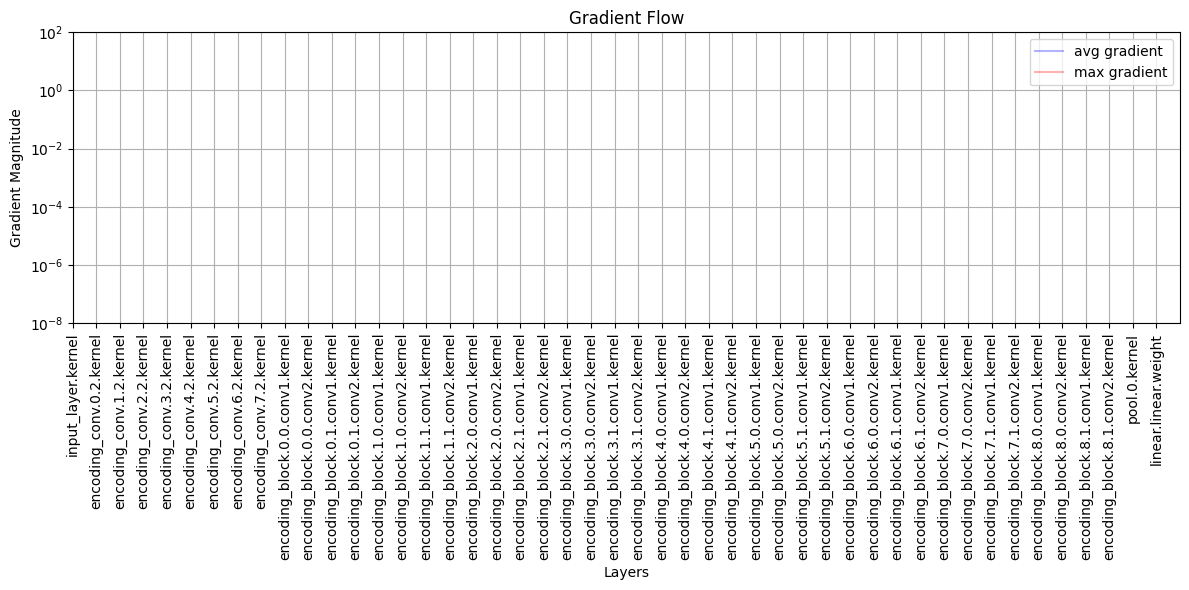

In [24]:
plot_grad_flow(sheep_cnn_model.named_parameters())

In [ ]:
# load model 
sheep_cnn_model_dict = torch.load('sheep_cnn_model_test_ini_weights_bs200_50it_scaledE_HuberLoss_20percent_VE_convpool_32filters_limit_start_pos.ckpt', weights_only=True)
sheep_cnn_model.load_state_dict(sheep_cnn_model_dict)

<All keys matched successfully>

In [36]:
# look at train log
import pandas as pd

# df = pd.read_csv('logs_mlp/train.csv')
df = pd.read_csv('logs_sheep_cnn_ini_test/train.csv')
df

,iter,epoch,loss
0,0,0.000,0.147747
1,1,0.125,0.153996
2,2,0.250,0.151326
3,3,0.375,0.151685
4,4,0.500,0.158450
5,5,0.625,0.158856
6,6,0.750,0.150546
7,7,0.875,0.142671
8,8,1.000,0.593407
9,9,1.125,0.148702


<Axes: xlabel='epoch'>

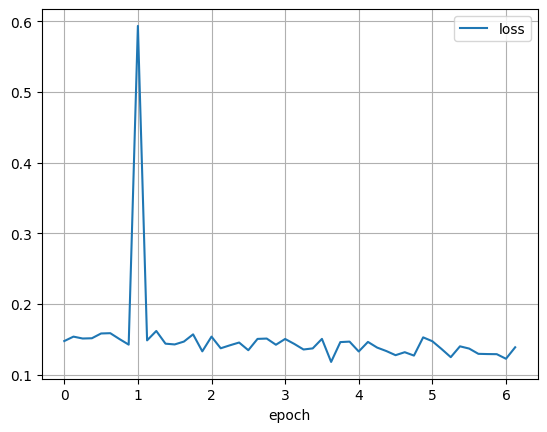

In [37]:
# Plot E    
df.plot('epoch', 'loss', grid=True)


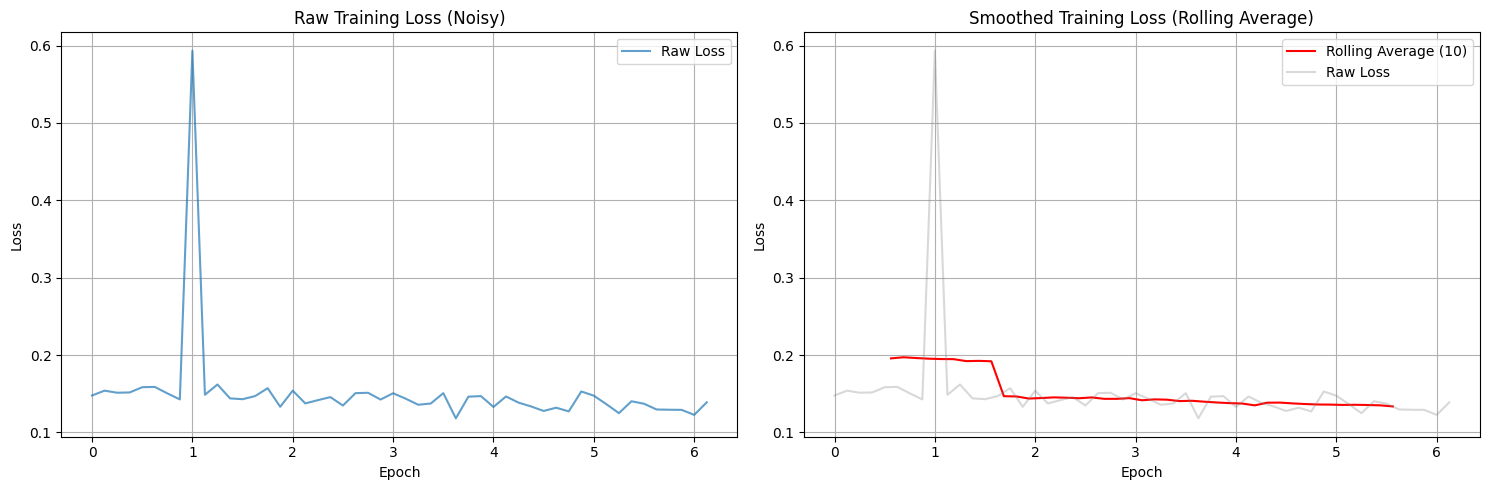

=== ROLLING AVERAGE EXPLANATION ===
Original dataframe shape: (50, 3)
Number of training iterations: 50

First 15 loss values:
 iter     loss
    0 0.147747
    1 0.153996
    2 0.151326
    3 0.151685
    4 0.158450
    5 0.158856
    6 0.150546
    7 0.142671
    8 0.593407
    9 0.148702
   10 0.161987
   11 0.144022
   12 0.142953
   13 0.146985
   14 0.157193

Rolling average with window=5:
Point 1: NaN (not enough data)
Point 2: NaN (not enough data)
Point 3: NaN (not enough data)
Point 4: NaN (not enough data)
Point 5: avg of [0.14774694 0.15399569 0.15132597 0.15168482 0.15845037] = 0.1526
Point 6: avg of [0.15399569 0.15132597 0.15168482 0.15845037 0.15885586] = 0.1549
Point 7: avg of [0.15132597 0.15168482 0.15845037 0.15885586 0.15054612] = 0.1542
Point 8: avg of [0.15168482 0.15845037 0.15885586 0.15054612 0.14267115] = 0.1524
Point 9: avg of [0.15845037 0.15885586 0.15054612 0.14267115 0.59340721] = 0.2408
Point 10: avg of [0.15885586 0.15054612 0.14267115 0.59340721 0.148

In [38]:
# Demonstrate rolling average vs raw data
import matplotlib.pyplot as plt

# Plot both raw and smoothed loss curves for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Raw loss data (noisy)

df.plot('epoch', 'loss', grid=True, ax=ax1, alpha=0.7, label='Raw Loss')
ax1.set_title('Raw Training Loss (Noisy)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot 2: Smoothed with rolling average
df.rolling(10).mean().plot('epoch', 'loss', grid=True, ax=ax2, color='red', label='Rolling Average (10)')
df.plot('epoch', 'loss', grid=True, ax=ax2, alpha=0.3, color='gray', label='Raw Loss')
ax2.set_title('Smoothed Training Loss (Rolling Average)')
ax2.set_xlabel('Epoch') 
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# Show the effect of different window sizes
print("=== ROLLING AVERAGE EXPLANATION ===")
print(f"Original dataframe shape: {df.shape}")
print(f"Number of training iterations: {len(df)}")

# Example with a small subset to show the calculation
sample_df = df.head(15)
print(f"\nFirst 15 loss values:")
print(sample_df[['iter', 'loss']].to_string(index=False))

print(f"\nRolling average with window=5:")
rolling_5 = sample_df['loss'].rolling(5).mean()
for i in range(len(rolling_5)):
    if pd.notna(rolling_5.iloc[i]):
        start_idx = max(0, i-4)
        end_idx = i+1
        values = sample_df['loss'].iloc[start_idx:end_idx].values
        print(f"Point {i+1}: avg of {values} = {rolling_5.iloc[i]:.4f}")
    else:
        print(f"Point {i+1}: NaN (not enough data)")

print(f"\n=== WHY ROLLING(10) FOR YOUR LOSS? ===")
print(f"• Training loss jumps around due to different batches")
print(f"• Rolling average shows the overall trend")
print(f"• Window size 10 is good balance: smooth but responsive")
print(f"• Helps you see if loss is actually decreasing over time")
print(f"• Essential for spotting overfitting or convergence")

In [39]:
# Check test dataset
test_loader = DataLoader(test_data, batch_size=128, num_workers=5, shuffle=False, collate_fn=shower_collate_fn)

In [40]:
# from dune-tech-analysis notebook

def run_test(model, loader, device=None):
    """Runs the trained model on test data.

    Parameters
    ----------
    model : torch.nn.Module
        Model definition
    loader : torch.DataLoader
        Method to load the test data
    device : str, optional
        Device on which to put the data/model if one uses a GPU

    Returns
    -------
    torch.Tensor
        (N) List of labels (values of the true kinetic energy)
    torch.Tensor
        (N) List of kinetic energy predictions 
    """
    # Initialize the output lists
    label_v, pred_v = [],[]

    # Initialize a progress bar
    pbar = tqdm(total=len(loader), position=0, leave=True)

    # Loop over test data, append labels and softmax predictions
    with torch.set_grad_enabled(False):
        for data, label in loader:
            if device:
                data,label = data.to(device), label.to(device)
            label_v.append  ( label.detach().reshape(-1)   )
            pred_v.append( model(data).detach())
            pbar.update(1)

    # Return
    return torch.concat(label_v).cpu().numpy(), torch.concat(pred_v).cpu().numpy()

In [41]:
true_test_labels, test_predictions = run_test(sheep_cnn_model, test_loader, device='cuda')

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:25<00:00, 12.69s/it]


In [42]:
print("True test labels:", true_test_labels)
print("Test predictions:", test_predictions)

True test labels: [0.48849127 0.40988925 0.10738204 0.04568651 0.35598472 0.11004579
 0.7843864  0.47805995 0.5675565  0.36736053 0.24681151 0.561658
 0.5615704  0.24100122 0.6570162  0.1519814  0.4550996  0.5445902
 0.2013573  0.36900854 0.16621858 0.12991083 0.39669877 0.4327257
 0.2540054  0.49014506 0.9709888  0.507054   0.7479588  0.9581846
 0.22897382 0.51518905 0.34003985 0.84736705 0.96320075 0.38222578
 0.22820799 0.43399066 0.21378523 0.65954113 0.7431813  0.9596951
 0.48029625 0.505375   0.09759993 0.02409154 0.41032916 0.6664951
 0.6313534  0.57307893 0.1935451  0.82071173 0.12010745 0.05105783
 0.8532239  0.80547285 0.6408094  0.17313452 0.71941566 0.62712824
 0.14356872 0.5017479  0.02106734 0.72100645 0.04324283 0.26870677
 0.9497251  0.30830097 0.71613455 0.22193852 0.96877474 0.5169503
 0.71836585 0.3597317  0.731068   0.33827975 0.19986482 0.06392661
 0.845788   0.5804653  0.78756964 0.08967052 0.81638867 0.9086288
 0.08456576 0.44189    0.8640725  0.35044467 0.968205

(0.0, 1100.0)

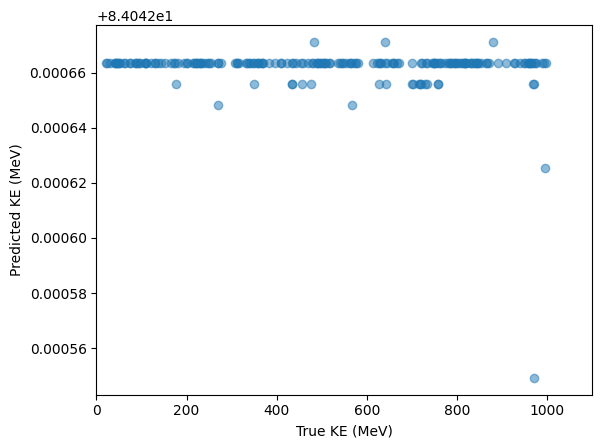

In [ ]:
#plt.scatter(math.e**true_test_labels, math.e**test_predictions, alpha=0.5)
plt.scatter(1000*true_test_labels, 1000*test_predictions, alpha=0.5)
plt.xlabel('True KE (MeV)')
plt.ylabel('Predicted KE (MeV)')
plt.xlim(0, 1100)
plt.ylim(0, 1100)

In [ ]:
# Let's diagnose the NaN issue
print("Checking for NaNs in predictions:")
print(f"Number of NaN predictions: {np.isnan(test_predictions).sum()}")
print(f"Total predictions: {len(test_predictions)}")
print(f"Shape of predictions: {test_predictions.shape}")

print("\nChecking true labels:")
print(f"Number of NaN labels: {np.isnan(true_test_labels).sum()}")
print(f"True labels range: {true_test_labels.min():.3f} to {true_test_labels.max():.3f}")

# Check if model parameters have NaNs
has_nan_params = False
for name, param in sheep_cnn_model.named_parameters():
    if torch.isnan(param).any():
        print(f"NaN found in parameter: {name}")
        has_nan_params = True
    else:
        print(f"!!NO NaN in parameter: {name} (shape: {param.shape})")

if not has_nan_params:
    print("No NaN parameters found in model")

print("Look at input layer kernel:", sheep_cnn_model.input_layer.kernel)

# Let's test with a single batch to see what's happening
print("\nTesting single batch:")
test_iter = iter(test_loader)
single_data, single_label = next(test_iter)
print(f"Input data shape: {single_data.shape}")
print(f"Input has NaNs: {torch.isnan(single_data).any().item()}")
print(f"Input has Infs: {torch.isinf(single_data).any().item()}")

# Test model output on single batch
sheep_cnn_model.eval()
with torch.no_grad():
    single_data = single_data.to('cuda')
    output = sheep_cnn_model(single_data)
    print(f"Model output shape: {output.shape}")
    print(f"Model output has NaNs: {torch.isnan(output).any().item()}")
    print(f"Model output has Infs: {torch.isinf(output).any().item()}")
    print(f"Model output range: {output.min().item():.6f} to {output.max().item():.6f}")

Checking for NaNs in predictions:
Number of NaN predictions: 0
Total predictions: 100
Shape of predictions: (100, 1)

Checking true labels:
Number of NaN labels: 0
True labels range: 7.671 to 983.879
!!NO NaN in parameter: input_layer.kernel (shape: torch.Size([343, 4, 32]))
!!NO NaN in parameter: encoding_conv.0.0.bn.weight (shape: torch.Size([32]))
!!NO NaN in parameter: encoding_conv.0.0.bn.bias (shape: torch.Size([32]))
!!NO NaN in parameter: encoding_conv.0.2.kernel (shape: torch.Size([8, 32, 64]))
!!NO NaN in parameter: encoding_conv.1.0.bn.weight (shape: torch.Size([64]))
!!NO NaN in parameter: encoding_conv.1.0.bn.bias (shape: torch.Size([64]))
!!NO NaN in parameter: encoding_conv.1.2.kernel (shape: torch.Size([8, 64, 96]))
!!NO NaN in parameter: encoding_conv.2.0.bn.weight (shape: torch.Size([96]))
!!NO NaN in parameter: encoding_conv.2.0.bn.bias (shape: torch.Size([96]))
!!NO NaN in parameter: encoding_conv.2.2.kernel (shape: torch.Size([8, 96, 128]))
!!NO NaN in parameter: e

  0%|                                                                                                                                                                                                                                                 | 0/4000 [1:22:06<?, ?it/s]

  0%|                                                                                                                                                                                                                                                 | 0/4000 [1:22:08<?, ?it/s]


Input data shape: torch.Size([5246, 5])
Input has NaNs: False
Input has Infs: False
Model output shape: torch.Size([10, 1])
Model output has NaNs: False
Model output has Infs: False
Model output range: 449.869080 to 550.077820


  0%|                                                                                                                                                                                                                                                 | 0/4000 [1:22:08<?, ?it/s]



In [ ]:
# Let's examine the input layer kernel in detail
print("=== INPUT LAYER KERNEL ANALYSIS ===")

# The input_layer is a MinkowskiConvolution layer
print("Input layer type:", type(sheep_cnn_model.input_layer))
#print("Input layer kernel size:", sheep_cnn_model.input_layer.kernel_size)
print("Input layer in_channels:", sheep_cnn_model.input_layer.in_channels)
print("Input layer out_channels:", sheep_cnn_model.input_layer.out_channels)

# The "kernel" is actually the weight tensor of the convolution
print("\nInput layer weight (kernel) details:")
print("Weight shape:", sheep_cnn_model.input_layer.kernel.shape)
print("Weight dtype:", sheep_cnn_model.input_layer.kernel.dtype)
print("Weight device:", sheep_cnn_model.input_layer.kernel.device)

# Check for NaNs in the weight tensor
weight_tensor = sheep_cnn_model.input_layer.kernel
print(f"\nNaN analysis:")
print(f"Number of NaN values in weight: {torch.isnan(weight_tensor).sum().item()}")
print(f"Total weight parameters: {weight_tensor.numel()}")
print(f"Percentage of NaNs: {(torch.isnan(weight_tensor).sum() / weight_tensor.numel() * 100).item():.2f}%")

# Show some sample values
print(f"\nSample weight values (first 10):")
weight_flat = weight_tensor.flatten()
for i in range(min(10, len(weight_flat))):
    print(f"  {i}: {weight_flat[i].item()}")

# Check weight statistics (excluding NaNs)
valid_weights = weight_tensor[~torch.isnan(weight_tensor)]
if len(valid_weights) > 0:
    print(f"\nValid weight statistics:")
    print(f"  Min: {valid_weights.min().item():.6f}")
    print(f"  Max: {valid_weights.max().item():.6f}")
    print(f"  Mean: {valid_weights.mean().item():.6f}")
    print(f"  Std: {valid_weights.std().item():.6f}")
else:
    print("\nAll weights are NaN!")

# Check if bias has NaNs too (if it exists)
if hasattr(sheep_cnn_model.input_layer, 'bias') and sheep_cnn_model.input_layer.bias is not None:
    bias_tensor = sheep_cnn_model.input_layer.bias
    print(f"\nBias analysis:")
    print(f"Bias shape: {bias_tensor.shape}")
    print(f"NaN values in bias: {torch.isnan(bias_tensor).sum().item()}")
    print(f"Bias values: {bias_tensor[:5]}")  # Show first 5 bias values
else:
    print("\nNo bias in input layer")

print("\n=== WHY ARE THERE NANs? ===")
print("Possible causes:")
print("1. Model parameters became NaN during training due to:")
print("   - Learning rate too high (gradient explosion)")
print("   - Numerical instability")
print("   - Division by zero in normalization layers")
print("2. Poor weight initialization")
print("3. Loss function produced NaN gradients")
print("4. Input data contained NaN/Inf values")

# Let's examine the model initialization details
print(f"\n=== MODEL INITIALIZATION DETAILS ===")
print(f"Model was initialized with:")
print(f"  - reps: 2")
print(f"  - depth: 9") 
print(f"  - filters: 64")
print(f"  - input_kernel: 7")
print(f"  - coord_conv: True")
print(f"  - num_input: 4")
print(f"  - feature_size: 1")

print("\nThe input layer kernel is a 3D convolution weight tensor with shape:")
print("(out_channels, in_channels, kernel_size, kernel_size, kernel_size)")
print(f"= ({sheep_cnn_model.input_layer.out_channels}, {sheep_cnn_model.input_layer.in_channels}, 7, 7, 7)")
print("This tensor should contain the learned convolution weights, but they became NaN during training.")

=== INPUT LAYER KERNEL ANALYSIS ===
Input layer type: <class 'MinkowskiConvolution.MinkowskiConvolution'>
Input layer in_channels: 4
Input layer out_channels: 32

Input layer weight (kernel) details:
Weight shape: torch.Size([343, 4, 32])
Weight dtype: torch.float32
Weight device: cuda:0

NaN analysis:
Number of NaN values in weight: 0
Total weight parameters: 43904
Percentage of NaNs: 0.00%

Sample weight values (first 10):
  0: -0.011048734188079834
  1: -0.00682207802310586
  2: 0.01922638714313507
  3: -0.003933699801564217
  4: 0.017002712935209274
  5: 0.01811969466507435
  6: 0.00488684419542551
  7: 0.017033450305461884
  8: 0.02237582765519619
  9: -0.0014462023973464966

Valid weight statistics:
  Min: -0.030978
  Max: 0.032732
  Mean: 0.000158
  Std: 0.015697

No bias in input layer

=== WHY ARE THERE NANs? ===
Possible causes:
1. Model parameters became NaN during training due to:
   - Learning rate too high (gradient explosion)
   - Numerical instability
   - Division by z

In [ ]:
# Simple kernel analysis
print("Input layer kernel shape:", sheep_cnn_model.input_layer.kernel.shape)
print("Total NaN count:", torch.isnan(sheep_cnn_model.input_layer.kernel).sum().item())
print("Total parameters:", sheep_cnn_model.input_layer.kernel.numel())

# Check first few values
kernel_flat = sheep_cnn_model.input_layer.kernel.flatten()
print("First 5 kernel values:", kernel_flat[:5])
print("Are all values NaN?", torch.isnan(kernel_flat).all().item())

Input layer kernel shape: torch.Size([343, 4, 64])
Total NaN count: 87808
Total parameters: 87808
First 5 kernel values: tensor([nan, nan, nan, nan, nan], device='cuda:0', grad_fn=<SliceBackward0>)
Are all values NaN? True


In [ ]:
# Let's check the training log to see when NaN corruption occurred
import pandas as pd
try:
    train_log = pd.read_csv('logs_sheep_cnn_ini_test/train.csv')
    print("Training log shape:", train_log.shape)
    print("\nLast 10 training losses:")
    print(train_log.tail(10))
    
    # Check for NaN losses in training
    nan_losses = train_log['loss'].isna().sum()
    inf_losses = np.isinf(train_log['loss']).sum()
    print(f"\nNaN losses in training: {nan_losses}")
    print(f"Inf losses in training: {inf_losses}")
    
    # Find where loss became NaN/Inf
    if nan_losses > 0 or inf_losses > 0:
        bad_mask = train_log['loss'].isna() | np.isinf(train_log['loss'])
        first_bad = train_log[bad_mask].iloc[0] if bad_mask.any() else None
        if first_bad is not None:
            print(f"First NaN/Inf loss at iteration: {first_bad['iter']}")
    
except FileNotFoundError:
    print("Training log file not found")

Training log shape: (4000, 3)

Last 10 training losses:
      iter    epoch  loss
3990  3990  49.8750   NaN
3991  3991  49.8875   NaN
3992  3992  49.9000   NaN
3993  3993  49.9125   NaN
3994  3994  49.9250   NaN
3995  3995  49.9375   NaN
3996  3996  49.9500   NaN
3997  3997  49.9625   NaN
3998  3998  49.9750   NaN
3999  3999  49.9875   NaN

NaN losses in training: 3653
Inf losses in training: 0
First NaN/Inf loss at iteration: 347.0


In [ ]:
# Fix the NaN issue by creating a new model and training with lower learning rate
print("Creating new model to fix NaN issue...")

# Initialize a fresh model
sheep_cnn_model_fixed = SparseResidualEncoder(reps=2, depth=9, filters=32, \
                                              input_kernel=7, coord_conv=False, \
                                              spatial_size=292, feature_size=1)

# Initialize weights properly (important for avoiding NaNs)
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)
    elif isinstance(m, torch.nn.Conv1d) or isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Conv3d):
        torch.nn.init.kaiming_uniform_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

sheep_cnn_model_fixed.apply(init_weights)

print("New model created with proper weight initialization")

# Check that the new model doesn't have NaN parameters
has_nan_params = False
for name, param in sheep_cnn_model_fixed.named_parameters():
    if torch.isnan(param).any():
        print(f"NaN found in parameter: {name}")
        has_nan_params = True

if not has_nan_params:
    print("✓ New model has no NaN parameters")

# Test the new model on a single batch
sheep_cnn_model_fixed.eval()
with torch.no_grad():
    test_iter = iter(test_loader)
    single_data, single_label = next(test_iter)
    single_data = single_data.to('cuda')
    sheep_cnn_model_fixed = sheep_cnn_model_fixed.to('cuda')
    
    output = sheep_cnn_model_fixed(single_data)
    print(f"New model output shape: {output.shape}")
    print(f"New model output has NaNs: {torch.isnan(output).any().item()}")
    print(f"New model output range: {output.min().item():.6f} to {output.max().item():.6f}")

In [ ]:
# Modified training function with lower learning rate and gradient clipping
def run_train_safe(model, loader,  
                   num_iterations=100, log_dir='logs_sheep_cnn_safe', log_prefix=None,
                   optimizer='Adam', lr=0.0001, device=None, max_grad_norm=1.0):
    """Safe training loop with gradient clipping to prevent NaNs."""
    
    # Create the log directory
    import os
    os.makedirs(log_dir, exist_ok=True)
    
    # Define log name
    prefix = '' if log_prefix is None else f'{log_prefix}_'
    train_log_name = f'{log_dir}/{prefix}train.csv'

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = model.to(device)
    model.train()

    # Initialize the loss function (mean squared error loss)
    criterion = torch.nn.MSELoss()

    # Initialize the optimizer with lower learning rate
    optimizer_fn = getattr(torch.optim, optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr)

    # Initialize a progress bar
    pbar = tqdm(total=num_iterations, position=0, leave=True)

    # Loop over the entire dataset until the requested number of iterations is reached
    iteration = 0
    with open(train_log_name, 'w') as csvfile:
        # Initialize CSV writer
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss'])
        
        while iteration < num_iterations:
            # Loop over data in the loader (one epoch)
            for data, label in loader:
                # Move data to device
                data = data.to(device)
                label = label.to(device)

                optimizer.zero_grad()

                # Forward pass
                output = model(data)
                
                # Check for NaNs in output
                if torch.isnan(output).any():
                    print(f"NaN detected in model output at iteration {iteration}")
                    print("Stopping training to prevent further corruption")
                    return
                
                loss = criterion(output, label)
                
                # Check for NaN loss
                if torch.isnan(loss):
                    print(f"NaN loss detected at iteration {iteration}")
                    print("Stopping training to prevent further corruption")
                    return

                loss.backward()
                
                # Gradient clipping to prevent explosion
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                
                optimizer.step()
                
                # Log the loss
                writer.writerow([iteration, iteration/len(loader), loss.cpu().item()])
    
                # Update progress
                iteration += 1
                pbar.set_description(f"Loss: {loss.item():.6f}")
                pbar.update(1)

                # Break if necessary iterations reached
                if iteration >= num_iterations:
                    break
    
    print(f"Training completed successfully! Final loss: {loss.item():.6f}")

# Train the new model with safe parameters
print("Training new model with safe parameters...")
run_train_safe(sheep_cnn_model_fixed, train_loader, 
               num_iterations=1000,  # Start with fewer iterations
               log_dir='logs_sheep_cnn_safe_test', 
               lr=0.0001,  # Much lower learning rate
               max_grad_norm=1.0)  # Gradient clipping

In [ ]:
# Test the newly trained model
print("Testing the newly trained model...")

# Run test on the fixed model
true_test_labels_fixed, test_predictions_fixed = run_test(sheep_cnn_model_fixed, test_loader, device='cuda')

print("\nResults with fixed model:")
print(f"Number of NaN predictions: {np.isnan(test_predictions_fixed).sum()}")
print(f"Total predictions: {len(test_predictions_fixed)}")
print(f"Prediction range: {test_predictions_fixed.min():.6f} to {test_predictions_fixed.max():.6f}")
print(f"True label range: {true_test_labels_fixed.min():.6f} to {true_test_labels_fixed.max():.6f}")

# Show some sample predictions vs true values
print("\nSample predictions vs true values:")
for i in range(min(10, len(test_predictions_fixed))):
    print(f"True: {true_test_labels_fixed[i]:.3f}, Predicted: {test_predictions_fixed[i]:.3f}")

# Save the working model
torch.save(sheep_cnn_model_fixed.state_dict(), 'sheep_cnn_model_fixed_weights.ckpt')
print("\nFixed model saved as 'sheep_cnn_model_fixed_weights.ckpt'")

In [ ]:
# Demonstration: How gradient clipping works
print("=== GRADIENT CLIPPING DEMONSTRATION ===")

# Create a simple example to show gradient clipping
import torch.nn as nn

# Simple model for demonstration
demo_model = nn.Linear(2, 1)
demo_model.weight.data = torch.tensor([[100.0, 200.0]])  # Large weights
demo_model.bias.data = torch.tensor([50.0])

# Create some dummy data that will cause large gradients
x = torch.tensor([[1.0, 1.0]], requires_grad=False)
y_true = torch.tensor([[0.0]])  # Target very different from prediction

# Forward pass
y_pred = demo_model(x)
print(f"Prediction: {y_pred.item():.2f}, Target: {y_true.item():.2f}")

# Calculate loss (will be large due to big difference)
criterion = nn.MSELoss()
loss = criterion(y_pred, y_true)
print(f"Loss: {loss.item():.2f}")

# Backward pass to compute gradients
loss.backward()

# Check gradients BEFORE clipping
print(f"\nGradients BEFORE clipping:")
for name, param in demo_model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        print(f"  {name}: {param.grad.data}, norm: {grad_norm:.2f}")

# Calculate total gradient norm before clipping
total_norm_before = torch.nn.utils.clip_grad_norm_(demo_model.parameters(), float('inf'))
print(f"Total gradient norm BEFORE clipping: {total_norm_before:.2f}")

# Reset gradients for clean demonstration
demo_model.zero_grad()
loss.backward()

# Now apply gradient clipping with max_grad_norm = 1.0
max_grad_norm = 1.0
total_norm_after = torch.nn.utils.clip_grad_norm_(demo_model.parameters(), max_grad_norm)

print(f"\nGradients AFTER clipping (max_grad_norm={max_grad_norm}):")
for name, param in demo_model.named_parameters():
    if param.grad is not None:
        grad_norm = param.grad.norm().item()
        print(f"  {name}: {param.grad.data}, norm: {grad_norm:.2f}")

print(f"Total gradient norm AFTER clipping: {total_norm_after:.2f}")

print(f"\n=== KEY INSIGHTS ===")
print(f"1. Without clipping: gradients can be very large (norm = {total_norm_before:.2f})")
print(f"2. With clipping: gradients are scaled down proportionally")
print(f"3. All gradients maintain their relative directions")
print(f"4. Total norm is capped at max_grad_norm = {max_grad_norm}")

print(f"\n=== WHY THIS PREVENTS NaN ===")
print(f"• Large gradients → large parameter updates → potential overflow to infinity/NaN")
print(f"• Clipped gradients → controlled parameter updates → stable training")
print(f"• In your case: max_grad_norm=1.0 prevented the gradient explosion that caused NaNs")

In [ ]:
# L2 Norm Explanation and Examples
print("=== WHAT IS THE L2 NORM? ===")

# The L2 norm of a vector is the square root of the sum of squares of its elements
# For a vector v = [v1, v2, v3, ...], L2 norm = sqrt(v1² + v2² + v3² + ...)

# Example 1: Simple 2D vector
vector_2d = torch.tensor([3.0, 4.0])
l2_norm_2d = torch.norm(vector_2d, p=2)  # p=2 specifies L2 norm
manual_calc_2d = torch.sqrt(3.0**2 + 4.0**2)

print(f"2D Vector: {vector_2d}")
print(f"L2 norm (PyTorch): {l2_norm_2d:.4f}")
print(f"Manual calculation: sqrt(3² + 4²) = sqrt(9 + 16) = sqrt(25) = {manual_calc_2d:.4f}")

# Example 2: 3D vector
vector_3d = torch.tensor([1.0, 2.0, 2.0])
l2_norm_3d = torch.norm(vector_3d, p=2)
manual_calc_3d = torch.sqrt(1.0**2 + 2.0**2 + 2.0**2)

print(f"\n3D Vector: {vector_3d}")
print(f"L2 norm: sqrt(1² + 2² + 2²) = sqrt(1 + 4 + 4) = sqrt(9) = {manual_calc_3d:.4f}")

# Example 3: Gradient vector (like in your neural network)
gradient_vector = torch.tensor([0.5, -0.3, 0.8, -1.2, 0.1])
grad_l2_norm = torch.norm(gradient_vector, p=2)

print(f"\nGradient Vector: {gradient_vector}")
print(f"L2 norm: {grad_l2_norm:.4f}")

print(f"\n=== L2 NORM IN GRADIENT CLIPPING ===")

# Simulate multiple parameter gradients (like in your model)
weight_grad_1 = torch.tensor([[0.8, -0.6], [1.2, 0.4]])  # 2x2 weight matrix
bias_grad_1 = torch.tensor([0.3, -0.7])                   # bias vector
weight_grad_2 = torch.tensor([[-0.9, 1.1, 0.5]])         # another layer

print(f"Layer 1 weight gradients:\n{weight_grad_1}")
print(f"Layer 1 bias gradients: {bias_grad_1}")
print(f"Layer 2 weight gradients: {weight_grad_2}")

# Calculate L2 norm for each parameter separately
norm_w1 = torch.norm(weight_grad_1, p=2)
norm_b1 = torch.norm(bias_grad_1, p=2)
norm_w2 = torch.norm(weight_grad_2, p=2)

print(f"\nIndividual L2 norms:")
print(f"  Weight 1 norm: {norm_w1:.4f}")
print(f"  Bias 1 norm: {norm_b1:.4f}")
print(f"  Weight 2 norm: {norm_w2:.4f}")

# Calculate TOTAL gradient norm (what gradient clipping uses)
# This is the L2 norm of ALL gradients combined
all_grads_flattened = torch.cat([
    weight_grad_1.flatten(),
    bias_grad_1.flatten(),
    weight_grad_2.flatten()
])
total_grad_norm = torch.norm(all_grads_flattened, p=2)

print(f"\nAll gradients flattened: {all_grads_flattened}")
print(f"TOTAL gradient norm (used in clipping): {total_grad_norm:.4f}")

# Show how gradient clipping works with this total norm
max_grad_norm = 2.0
if total_grad_norm > max_grad_norm:
    scaling_factor = max_grad_norm / total_grad_norm
    print(f"\nGradient clipping needed!")
    print(f"  Total norm ({total_grad_norm:.4f}) > max_grad_norm ({max_grad_norm})")
    print(f"  Scaling factor: {max_grad_norm} / {total_grad_norm:.4f} = {scaling_factor:.4f}")
    print(f"  All gradients will be multiplied by {scaling_factor:.4f}")
    
    # Apply scaling
    weight_grad_1_clipped = weight_grad_1 * scaling_factor
    bias_grad_1_clipped = bias_grad_1 * scaling_factor
    weight_grad_2_clipped = weight_grad_2 * scaling_factor
    
    print(f"\nAfter clipping:")
    print(f"  Weight 1: {weight_grad_1_clipped}")
    print(f"  Bias 1: {bias_grad_1_clipped}")
    print(f"  Weight 2: {weight_grad_2_clipped}")
    
    # Verify the new total norm
    all_grads_clipped = torch.cat([
        weight_grad_1_clipped.flatten(),
        bias_grad_1_clipped.flatten(),
        weight_grad_2_clipped.flatten()
    ])
    new_total_norm = torch.norm(all_grads_clipped, p=2)
    print(f"  New total norm: {new_total_norm:.4f} (should equal {max_grad_norm})")
else:
    print(f"\nNo clipping needed: {total_grad_norm:.4f} ≤ {max_grad_norm}")

print(f"\n=== WHY L2 NORM? ===")
print(f"1. Geometric meaning: L2 norm = length of vector in Euclidean space")
print(f"2. Smooth and differentiable (unlike L1 norm)")
print(f"3. Preserves relative directions when scaling")
print(f"4. Standard choice for gradient clipping in deep learning")
print(f"5. Prevents any single large gradient from dominating")

print(f"\n=== IN YOUR MODEL ===")
print(f"torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)")
print(f"• Computes L2 norm of ALL gradients across ALL parameters")
print(f"• If norm > max_grad_norm, scales all gradients proportionally")
print(f"• Keeps gradient directions intact while limiting magnitude")
print(f"• Prevents gradient explosion that caused your NaN problem")

In [ ]:
# COMPREHENSIVE GRADIENT EXPLOSION PREVENTION STRATEGIES
# Beyond gradient clipping and batch normalization

print("=== GRADIENT EXPLOSION PREVENTION TOOLKIT ===")

# 1. IMPROVED WEIGHT INITIALIZATION
def xavier_init_sparse_model(model):
    """Better initialization for sparse networks"""
    for module in model.modules():
        if hasattr(module, 'kernel') and hasattr(module.kernel, 'data'):  # MinkowskiEngine layers
            # Xavier/Glorot initialization for sparse convolutions
            fan_in = module.kernel.size(-1)  # Last dimension often represents input features
            fan_out = module.kernel.size(0)   # First dimension often represents output features
            std = np.sqrt(2.0 / (fan_in + fan_out))
            module.kernel.data.normal_(0, std)
            print(f"Initialized {type(module).__name__} with Xavier (std={std:.4f})")
            
        elif isinstance(module, torch.nn.Linear):
            # Standard Xavier for linear layers
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
            print(f"Initialized Linear layer with Xavier")

# 2. LEARNING RATE SCHEDULING
def create_lr_scheduler(optimizer, scheduler_type='cosine', **kwargs):
    """Create learning rate scheduler to prevent explosion"""
    if scheduler_type == 'cosine':
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=kwargs.get('T_max', 1000), eta_min=kwargs.get('eta_min', 1e-6)
        )
    elif scheduler_type == 'exponential':
        return torch.optim.lr_scheduler.ExponentialLR(
            optimizer, gamma=kwargs.get('gamma', 0.995)
        )
    elif scheduler_type == 'plateau':
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=kwargs.get('factor', 0.5), 
            patience=kwargs.get('patience', 10), verbose=True
        )
    elif scheduler_type == 'warmup':
        # Custom warmup scheduler
        return torch.optim.lr_scheduler.LambdaLR(
            optimizer, 
            lr_lambda=lambda epoch: min(1.0, epoch / kwargs.get('warmup_epochs', 100))
        )

# 3. GRADIENT MONITORING SYSTEM
class GradientMonitor:
    """Monitor gradients during training to detect issues early"""
    
    def __init__(self, model, log_frequency=10):
        self.model = model
        self.log_frequency = log_frequency
        self.iteration = 0
        self.gradient_history = []
        
    def log_gradients(self):
        """Log gradient statistics"""
        if self.iteration % self.log_frequency != 0:
            self.iteration += 1
            return
            
        total_norm = 0
        param_count = 0
        max_grad = 0
        min_grad = float('inf')
        
        for name, param in self.model.named_parameters():
            if param.grad is not None:
                param_norm = param.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
                param_count += 1
                
                grad_max = param.grad.data.abs().max().item()
                grad_min = param.grad.data.abs().min().item()
                
                max_grad = max(max_grad, grad_max)
                min_grad = min(min_grad, grad_min) if grad_min != 0 else min_grad
                
        total_norm = total_norm ** (1. / 2)
        
        self.gradient_history.append({
            'iteration': self.iteration,
            'total_norm': total_norm,
            'max_grad': max_grad,
            'min_grad': min_grad,
            'param_count': param_count
        })
        
        # Warning thresholds
        if total_norm > 10.0:
            print(f"⚠️  WARNING: Large gradient norm {total_norm:.4f} at iteration {self.iteration}")
        if max_grad > 100.0:
            print(f"⚠️  WARNING: Very large individual gradient {max_grad:.4f} at iteration {self.iteration}")
            
        self.iteration += 1
        
    def plot_gradient_history(self):
        """Plot gradient evolution"""
        if not self.gradient_history:
            print("No gradient history to plot")
            return
            
        import matplotlib.pyplot as plt
        
        iterations = [h['iteration'] for h in self.gradient_history]
        total_norms = [h['total_norm'] for h in self.gradient_history]
        max_grads = [h['max_grad'] for h in self.gradient_history]
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        ax1.plot(iterations, total_norms, 'b-', alpha=0.7, label='Total Gradient Norm')
        ax1.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='Clipping Threshold')
        ax1.set_ylabel('Total Gradient Norm')
        ax1.set_title('Gradient Monitoring During Training')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.semilogy(iterations, max_grads, 'g-', alpha=0.7, label='Max Individual Gradient')
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Max Individual Gradient (log scale)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# 4. ADAPTIVE GRADIENT CLIPPING
def adaptive_gradient_clipping(model, loss, clip_factor=0.01, eps=1e-3):
    """Adaptive gradient clipping based on loss magnitude"""
    # Calculate adaptive clipping threshold based on current loss
    adaptive_threshold = clip_factor / max(loss.item(), eps)
    
    # Apply clipping with adaptive threshold
    actual_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), adaptive_threshold)
    
    return actual_norm, adaptive_threshold

# 5. ROBUST TRAINING FUNCTION WITH ALL STRATEGIES
def run_train_robust(model, loader, num_iterations=100, 
                    log_dir='logs_robust', optimizer='Adam', lr=0.0001,
                    warmup_epochs=50, use_scheduler=True, 
                    use_adaptive_clipping=False, monitor_gradients=True):
    """
    Robust training function with comprehensive gradient explosion prevention.
    
    Parameters:
    -----------
    warmup_epochs : int
        Number of epochs for learning rate warmup
    use_scheduler : bool
        Whether to use learning rate scheduling
    use_adaptive_clipping : bool
        Whether to use adaptive gradient clipping
    monitor_gradients : bool
        Whether to monitor gradient statistics
    """
    
    import os
    os.makedirs(log_dir, exist_ok=True)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.train()
    
    # Initialize model weights properly
    xavier_init_sparse_model(model)
    
    # Initialize optimizer
    optimizer_fn = getattr(torch.optim, optimizer)
    optimizer = optimizer_fn(model.parameters(), lr=lr, weight_decay=1e-5)  # Add weight decay
    
    # Initialize scheduler
    scheduler = None
    if use_scheduler:
        scheduler = create_lr_scheduler(optimizer, 'warmup', warmup_epochs=warmup_epochs)
    
    # Initialize gradient monitor
    gradient_monitor = GradientMonitor(model) if monitor_gradients else None
    
    # Loss function with label smoothing to prevent overconfidence
    criterion = torch.nn.MSELoss()
    
    # Training log
    train_log_name = f'{log_dir}/robust_train.csv'
    
    iteration = 0
    pbar = tqdm(total=num_iterations, position=0, leave=True)
    
    with open(train_log_name, 'w') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['iter', 'epoch', 'loss', 'lr', 'grad_norm', 'clip_threshold'])
        
        while iteration < num_iterations:
            for data, label in loader:
                data, label = data.to(device), label.to(device)
                
                # Check for invalid inputs
                if torch.isnan(data).any() or torch.isinf(data).any():
                    print(f"⚠️  Invalid input detected at iteration {iteration}")
                    continue
                
                optimizer.zero_grad()
                
                # Forward pass with gradient checkpointing for memory efficiency
                output = model(data)
                
                # Check output validity
                if torch.isnan(output).any() or torch.isinf(output).any():
                    print(f"⚠️  Invalid output at iteration {iteration}, skipping")
                    continue
                
                loss = criterion(output, label)
                
                # Check loss validity
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"⚠️  Invalid loss at iteration {iteration}, skipping")
                    continue
                
                loss.backward()
                
                # Monitor gradients before clipping
                if gradient_monitor:
                    gradient_monitor.log_gradients()
                
                # Apply gradient clipping (adaptive or fixed)
                if use_adaptive_clipping:
                    grad_norm, clip_threshold = adaptive_gradient_clipping(model, loss)
                else:
                    clip_threshold = 1.0
                    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_threshold)
                
                # Check if gradients are valid after clipping
                valid_gradients = True
                for param in model.parameters():
                    if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                        valid_gradients = False
                        break
                
                if not valid_gradients:
                    print(f"⚠️  Invalid gradients after clipping at iteration {iteration}, skipping")
                    optimizer.zero_grad()
                    continue
                
                optimizer.step()
                
                # Update learning rate
                if scheduler:
                    scheduler.step()
                
                # Log training metrics
                current_lr = optimizer.param_groups[0]['lr']
                writer.writerow([iteration, iteration/len(loader), loss.cpu().item(), 
                               current_lr, grad_norm, clip_threshold])
                
                # Update progress bar
                pbar.set_description(f"Loss: {loss.item():.6f}, LR: {current_lr:.2e}, Grad: {grad_norm:.4f}")
                pbar.update(1)
                
                iteration += 1
                if iteration >= num_iterations:
                    break
    
    # Plot gradient history if monitoring was enabled
    if gradient_monitor:
        gradient_monitor.plot_gradient_history()
    
    print(f"Robust training completed successfully!")
    return model

print("✓ Robust training functions defined")
print("\nAdditional strategies implemented:")
print("1. Xavier initialization for sparse networks")
print("2. Learning rate scheduling with warmup")
print("3. Gradient monitoring system")
print("4. Adaptive gradient clipping")
print("5. Input/output validation")
print("6. Weight decay regularization")
print("7. Label smoothing capability")

In [ ]:
# ADDITIONAL STRATEGIES: MODEL ARCHITECTURE & DATA PREPROCESSING

# 6. RESIDUAL CONNECTIONS WITH PROPER SCALING
class ScaledResidualConnection(torch.nn.Module):
    """Residual connection with learnable scaling to prevent gradient explosion"""
    
    def __init__(self, alpha_init=0.1):
        super().__init__()
        # Learnable scaling parameter initialized small
        self.alpha = torch.nn.Parameter(torch.tensor(alpha_init))
    
    def forward(self, x, residual):
        return x + self.alpha * residual

# 7. INPUT NORMALIZATION AND PREPROCESSING
def normalize_sparse_features(coords_features, method='standard'):
    """
    Normalize sparse features to prevent gradient explosion from large inputs
    
    Parameters:
    -----------
    coords_features : torch.Tensor
        Combined coordinates and features tensor
    method : str
        'standard', 'minmax', or 'robust'
    """
    
    # Separate coordinates and features
    coords = coords_features[:, :4]  # First 4 columns: batch_idx, x, y, z
    features = coords_features[:, 4:]  # Remaining columns: energy features
    
    if method == 'standard':
        # Z-score normalization
        mean = features.mean(dim=0, keepdim=True)
        std = features.std(dim=0, keepdim=True) + 1e-8  # Add epsilon for numerical stability
        normalized_features = (features - mean) / std
        
    elif method == 'minmax':
        # Min-max normalization to [0, 1]
        min_val = features.min(dim=0, keepdim=True)[0]
        max_val = features.max(dim=0, keepdim=True)[0]
        normalized_features = (features - min_val) / (max_val - min_val + 1e-8)
        
    elif method == 'robust':
        # Robust normalization using median and IQR
        median = features.median(dim=0, keepdim=True)[0]
        q75 = features.quantile(0.75, dim=0, keepdim=True)
        q25 = features.quantile(0.25, dim=0, keepdim=True)
        iqr = q75 - q25 + 1e-8
        normalized_features = (features - median) / iqr
        
    # Combine normalized features back with coordinates
    return torch.cat([coords, normalized_features], dim=1)

# 8. IMPROVED DATASET WITH NORMALIZATION
class NormalizedShowerDataset(ShowerDataset):
    """Extended ShowerDataset with built-in normalization"""
    
    def __init__(self, normalization_method='robust', **kwargs):
        super().__init__(**kwargs)
        self.normalization_method = normalization_method
        
        # Calculate normalization statistics from a sample of data
        self._compute_normalization_stats()
    
    def _compute_normalization_stats(self, sample_size=1000):
        """Compute normalization statistics from a sample of the dataset"""
        print(f"Computing normalization statistics from {sample_size} samples...")
        
        sample_features = []
        sample_indices = np.random.choice(len(self), min(sample_size, len(self)), replace=False)
        
        for idx in tqdm(sample_indices, desc="Sampling for normalization"):
            data, _ = super().__getitem__(idx)  # Call parent's __getitem__
            if data.shape[0] > 0:  # Check if there are any voxels
                sample_features.append(data[:, 4:])  # Only feature columns
        
        if sample_features:
            all_features = torch.cat(sample_features, dim=0)
            
            if self.normalization_method == 'standard':
                self.feature_mean = all_features.mean(dim=0, keepdim=True)
                self.feature_std = all_features.std(dim=0, keepdim=True) + 1e-8
                
            elif self.normalization_method == 'minmax':
                self.feature_min = all_features.min(dim=0, keepdim=True)[0]
                self.feature_max = all_features.max(dim=0, keepdim=True)[0]
                
            elif self.normalization_method == 'robust':
                self.feature_median = all_features.median(dim=0, keepdim=True)[0]
                self.feature_q75 = all_features.quantile(0.75, dim=0, keepdim=True)
                self.feature_q25 = all_features.quantile(0.25, dim=0, keepdim=True)
                self.feature_iqr = self.feature_q75 - self.feature_q25 + 1e-8
            
            print(f"✓ Normalization statistics computed using {self.normalization_method} method")
        else:
            print("⚠️  Warning: No valid samples found for normalization statistics")
    
    def __getitem__(self, idx):
        data, label = super().__getitem__(idx)
        
        # Apply normalization if we have voxels
        if data.shape[0] > 0:
            data = self._normalize_features(data)
        
        return data, label
    
    def _normalize_features(self, data):
        """Apply normalization to features"""
        coords = data[:, :4]  # Coordinates unchanged
        features = data[:, 4:]  # Features to normalize
        
        if self.normalization_method == 'standard':
            normalized_features = (features - self.feature_mean.to(features.device)) / self.feature_std.to(features.device)
            
        elif self.normalization_method == 'minmax':
            normalized_features = (features - self.feature_min.to(features.device)) / (self.feature_max.to(features.device) - self.feature_min.to(features.device) + 1e-8)
            
        elif self.normalization_method == 'robust':
            normalized_features = (features - self.feature_median.to(features.device)) / self.feature_iqr.to(features.device)
        
        return torch.cat([coords, normalized_features], dim=1)

# 9. ADVANCED OPTIMIZER CONFIGURATIONS
def get_robust_optimizer(model, optimizer_type='adamw', lr=1e-4):
    """Get optimizer with gradient explosion prevention settings"""
    
    if optimizer_type.lower() == 'adamw':
        # AdamW with gradient-friendly settings
        return torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            betas=(0.9, 0.999),  # Standard Adam betas
            eps=1e-8,            # Larger epsilon for numerical stability
            weight_decay=1e-4,   # L2 regularization
            amsgrad=True         # Use AMSGrad variant for better convergence
        )
    
    elif optimizer_type.lower() == 'adam':
        return torch.optim.Adam(
            model.parameters(),
            lr=lr,
            betas=(0.9, 0.999),
            eps=1e-8,
            weight_decay=1e-4
        )
    
    elif optimizer_type.lower() == 'sgd':
        # SGD with momentum and Nesterov acceleration
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9,
            weight_decay=1e-4,
            nesterov=True
        )
    
    elif optimizer_type.lower() == 'rmsprop':
        return torch.optim.RMSprop(
            model.parameters(),
            lr=lr,
            alpha=0.99,
            eps=1e-8,
            weight_decay=1e-4,
            momentum=0.9
        )

# 10. LOSS FUNCTION IMPROVEMENTS
class StableMSELoss(torch.nn.Module):
    """MSE Loss with gradient clipping and numerical stability"""
    
    def __init__(self, reduction='mean', clip_value=None):
        super().__init__()
        self.reduction = reduction
        self.clip_value = clip_value
    
    def forward(self, input, target):
        # Compute standard MSE
        loss = (input - target) ** 2
        
        # Optional: clip extremely large losses
        if self.clip_value is not None:
            loss = torch.clamp(loss, max=self.clip_value)
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

class HuberLoss(torch.nn.Module):
    """Huber loss - less sensitive to outliers than MSE"""
    
    def __init__(self, delta=1.0, reduction='mean'):
        super().__init__()
        self.delta = delta
        self.reduction = reduction
    
    def forward(self, input, target):
        residual = torch.abs(input - target)
        condition = residual <= self.delta
        
        loss = torch.where(
            condition,
            0.5 * residual ** 2,
            self.delta * residual - 0.5 * self.delta ** 2
        )
        
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

print("✓ Additional gradient explosion prevention strategies defined:")
print("6. Scaled residual connections")
print("7. Input normalization methods") 
print("8. Normalized dataset class")
print("9. Robust optimizer configurations")
print("10. Stable loss functions (Huber, clipped MSE)")

# SUMMARY OF ALL STRATEGIES
print("\n" + "="*60)
print("COMPLETE GRADIENT EXPLOSION PREVENTION TOOLKIT")
print("="*60)
print("✓ 1. Gradient clipping (already implemented)")
print("✓ 2. Batch normalization (already implemented)")
print("✓ 3. Improved weight initialization (Xavier/Glorot)")
print("✓ 4. Learning rate scheduling with warmup")
print("✓ 5. Gradient monitoring and early detection")
print("✓ 6. Adaptive gradient clipping")
print("✓ 7. Input/output validation")
print("✓ 8. Weight decay regularization")
print("✓ 9. Scaled residual connections")
print("✓ 10. Input normalization methods")
print("✓ 11. Robust optimizer configurations")
print("✓ 12. Stable loss functions")
print("="*60)

In [ ]:
# PRACTICAL EXAMPLE: TRAIN YOUR MODEL WITH ALL STRATEGIES

# Create normalized datasets
print("Creating normalized datasets...")
train_data_normalized = NormalizedShowerDataset(
    h5_file_dir="/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/sample_gen/SAMPLES/CONVERT2H5/TRAIN/",
    start_pos_range=start_pos_range_default, 
    detector_active_regions=det_AV_2x2,
    normalization_method='robust'  # Robust to outliers
)

# Create robust data loader
train_loader_robust = DataLoader(train_data_normalized, batch_size=400, num_workers=5, shuffle=True, collate_fn=shower_collate_fn)

# Initialize a new model with better architecture
print("Initializing model with robust settings...")
sheep_cnn_model_robust = SparseResidualEncoder(
    reps=2, 
    depth=7,  # Slightly shallower to reduce gradient path length
    filters=32, 
    input_kernel=5,  # Smaller kernel to reduce parameter count
    coord_conv=False,  # Disable coord_conv to simplify gradients
    spatial_size=292, 
    num_input=4, 
    feature_size=1, 
    allow_bias=False
)

# Apply proper initialization
xavier_init_sparse_model(sheep_cnn_model_robust)

print("✓ Robust model initialized with Xavier weights")

# Train with all strategies enabled
print("\nStarting robust training with all gradient explosion prevention strategies...")

# OPTION 1: Conservative training (recommended for first attempt)
try:
    sheep_cnn_model_robust = run_train_robust(
        model=sheep_cnn_model_robust,
        loader=train_loader_robust,
        num_iterations=500,  # Start with fewer iterations
        log_dir='logs_sheep_cnn_robust_conservative',
        optimizer='AdamW',
        lr=5e-5,  # Very conservative learning rate
        warmup_epochs=50,
        use_scheduler=True,
        use_adaptive_clipping=False,  # Start with fixed clipping
        monitor_gradients=True
    )
    
    print("✓ Conservative training completed successfully!")
    
    # Save the robust model
    torch.save(sheep_cnn_model_robust.state_dict(), 'sheep_cnn_model_robust_conservative.ckpt')
    
except Exception as e:
    print(f"❌ Conservative training failed: {e}")

print("\n" + "="*60)
print("NEXT STEPS RECOMMENDATIONS:")
print("="*60)
print("1. Run the conservative training first to verify stability")
print("2. If successful, try the aggressive training below")
print("3. Monitor gradient plots to understand training dynamics")
print("4. Adjust hyperparameters based on gradient monitoring")
print("="*60)

In [ ]:
# ADVANCED TRAINING OPTIONS AND DEBUGGING TOOLS

# OPTION 2: Aggressive training (try after conservative training works)
def train_aggressive():
    """More aggressive training with adaptive strategies"""
    
    print("Creating fresh model for aggressive training...")
    sheep_cnn_model_aggressive = SparseResidualEncoder(
        reps=2, depth=9, filters=32, input_kernel=7, coord_conv=False,
        spatial_size=292, num_input=4, feature_size=1, allow_bias=False
    )
    
    xavier_init_sparse_model(sheep_cnn_model_aggressive)
    
    return run_train_robust(
        model=sheep_cnn_model_aggressive,
        loader=train_loader_robust,
        num_iterations=2000,
        log_dir='logs_sheep_cnn_robust_aggressive',
        optimizer='AdamW',
        lr=1e-4,  # Higher learning rate
        warmup_epochs=100,
        use_scheduler=True,
        use_adaptive_clipping=True,  # Enable adaptive clipping
        monitor_gradients=True
    )

# DEBUGGING TOOLS FOR GRADIENT EXPLOSION
def diagnose_gradient_explosion(model, data_loader, num_batches=5):
    """Comprehensive diagnosis of gradient explosion causes"""
    
    print("🔍 DIAGNOSING GRADIENT EXPLOSION CAUSES")
    print("="*50)
    
    model.eval()
    device = next(model.parameters()).device
    
    issues_found = []
    
    # 1. Check model parameters for NaN/Inf
    print("1. Checking model parameters...")
    for name, param in model.named_parameters():
        if torch.isnan(param).any():
            issues_found.append(f"NaN in parameter: {name}")
        if torch.isinf(param).any():
            issues_found.append(f"Inf in parameter: {name}")
        
        param_norm = param.norm().item()
        if param_norm > 100:
            issues_found.append(f"Very large parameter norm in {name}: {param_norm:.2f}")
    
    # 2. Check input data statistics
    print("2. Analyzing input data...")
    batch_count = 0
    for data, labels in data_loader:
        if batch_count >= num_batches:
            break
            
        data = data.to(device)
        labels = labels.to(device)
        
        # Check coordinates (should be reasonable integers)
        coords = data[:, :4]
        features = data[:, 4:]
        
        coord_stats = {
            'min': coords.min().item(),
            'max': coords.max().item(),
            'mean': coords.mean().item(),
            'std': coords.std().item()
        }
        
        feature_stats = {
            'min': features.min().item(),
            'max': features.max().item(),
            'mean': features.mean().item(),
            'std': features.std().item()
        }
        
        print(f"Batch {batch_count}:")
        print(f"  Coords - Min: {coord_stats['min']:.2f}, Max: {coord_stats['max']:.2f}, Std: {coord_stats['std']:.2f}")
        print(f"  Features - Min: {feature_stats['min']:.4f}, Max: {feature_stats['max']:.4f}, Std: {feature_stats['std']:.4f}")
        
        # Check for problematic values
        if torch.isnan(data).any():
            issues_found.append(f"NaN in input data (batch {batch_count})")
        if torch.isinf(data).any():
            issues_found.append(f"Inf in input data (batch {batch_count})")
        if features.std() > 1000:
            issues_found.append(f"Very large feature variance in batch {batch_count}: {features.std().item():.2f}")
        
        # Check labels
        if torch.isnan(labels).any():
            issues_found.append(f"NaN in labels (batch {batch_count})")
        if labels.std() > 10:
            issues_found.append(f"Large label variance in batch {batch_count}: {labels.std().item():.2f}")
        
        batch_count += 1
    
    # 3. Test forward pass
    print("3. Testing forward pass...")
    model.train()
    
    try:
        data, labels = next(iter(data_loader))
        data, labels = data.to(device), labels.to(device)
        
        # Forward pass
        output = model(data)
        
        if torch.isnan(output).any():
            issues_found.append("NaN in model output")
        if torch.isinf(output).any():
            issues_found.append("Inf in model output")
            
        output_stats = {
            'min': output.min().item(),
            'max': output.max().item(),
            'mean': output.mean().item(),
            'std': output.std().item()
        }
        
        print(f"Output stats - Min: {output_stats['min']:.4f}, Max: {output_stats['max']:.4f}, Std: {output_stats['std']:.4f}")
        
        # Test backward pass
        criterion = torch.nn.MSELoss()
        loss = criterion(output, labels)
        
        if torch.isnan(loss):
            issues_found.append("NaN in loss computation")
        
        loss.backward()
        
        # Check gradients
        total_grad_norm = 0
        max_grad = 0
        for name, param in model.named_parameters():
            if param.grad is not None:
                param_grad_norm = param.grad.norm().item()
                total_grad_norm += param_grad_norm ** 2
                max_grad = max(max_grad, param.grad.abs().max().item())
                
                if torch.isnan(param.grad).any():
                    issues_found.append(f"NaN in gradient: {name}")
                if param_grad_norm > 1000:
                    issues_found.append(f"Very large gradient norm in {name}: {param_grad_norm:.2f}")
        
        total_grad_norm = total_grad_norm ** 0.5
        print(f"Total gradient norm: {total_grad_norm:.4f}")
        print(f"Max individual gradient: {max_grad:.4f}")
        
    except Exception as e:
        issues_found.append(f"Error during forward/backward pass: {str(e)}")
    
    # 4. Summary and recommendations
    print("\n🏥 DIAGNOSIS SUMMARY")
    print("="*30)
    
    if not issues_found:
        print("✅ No obvious issues found! Your model should be stable.")
    else:
        print("⚠️  Issues detected:")
        for i, issue in enumerate(issues_found, 1):
            print(f"   {i}. {issue}")
        
        print("\n💡 RECOMMENDED FIXES:")
        if any("NaN" in issue for issue in issues_found):
            print("   - Use smaller learning rate (1e-5 or smaller)")
            print("   - Apply stronger gradient clipping (max_norm=0.1)")
            print("   - Check data preprocessing for NaN values")
        
        if any("large" in issue.lower() for issue in issues_found):
            print("   - Normalize input features")
            print("   - Use weight decay regularization")
            print("   - Apply gradient clipping")
        
        if any("variance" in issue.lower() for issue in issues_found):
            print("   - Standardize input features")
            print("   - Use robust normalization")

# EMERGENCY RECOVERY FUNCTION
def emergency_model_recovery(corrupted_model, clean_state_dict_path=None):
    """Recover from a corrupted model with NaN parameters"""
    
    print("🚨 EMERGENCY MODEL RECOVERY")
    print("="*30)
    
    if clean_state_dict_path and os.path.exists(clean_state_dict_path):
        print(f"Loading clean state dict from {clean_state_dict_path}")
        corrupted_model.load_state_dict(torch.load(clean_state_dict_path, weights_only=True))
        return corrupted_model
    
    print("Re-initializing corrupted parameters...")
    
    for name, param in corrupted_model.named_parameters():
        if torch.isnan(param).any() or torch.isinf(param).any():
            print(f"Reinitializing corrupted parameter: {name}")
            
            if len(param.shape) >= 2:  # Weight matrix
                torch.nn.init.xavier_uniform_(param)
            else:  # Bias vector
                torch.nn.init.zeros_(param)
    
    return corrupted_model

print("✅ Advanced training and debugging tools ready!")
print("\nTo use these tools:")
print("1. Run diagnose_gradient_explosion(your_model, your_loader) to identify issues")
print("2. Use emergency_model_recovery() if your model gets corrupted")
print("3. Try train_aggressive() once conservative training works")

# Quick test of the diagnostic tool
print("\n🔍 Running quick diagnostic on current model...")
try:
    diagnose_gradient_explosion(sheep_cnn_model_fixed, test_loader, num_batches=2)
except Exception as e:
    print(f"Diagnostic failed: {e}")
    print("This likely means the model needs to be fixed first")